In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Rotten Tomatoes Rating Prediction
## Full ML Pipeline: EDA → Feature Engineering → NLP → Modelling → Evaluation

### Problem Statement
Predict whether a movie is labeled 'Rotten', 'Fresh', or 'Certified-Fresh'
using both structured movie metadata AND unstructured critic review text.

### This is a 3-class classification problem with:
- Mixed data types (structured + text)
- Class imbalance (Certified-Fresh is rare)
- Data leakage risk (rating columns directly define the label)
- Multi-value categorical columns (genres, directors, actors)
- Free text requiring NLP preprocessing

### Data Sources:
- rotten_tomatoes_movies.csv      → structured movie features + TARGET
- rotten_tomatoes_movie_reviews.csv → 50k critic reviews → NLP features

In [2]:
# ── CELL 1: Imports + Load + First Audit ──────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 80)

MOVIES_PATH  = "/kaggle/input/datasets/andrezaza/clapper-massive-rotten-tomatoes-movies-and-reviews/rotten_tomatoes_movies.csv"
REVIEWS_PATH = "/kaggle/input/datasets/andrezaza/clapper-massive-rotten-tomatoes-movies-and-reviews/rotten_tomatoes_movie_reviews.csv"

# Load both
movies  = pd.read_csv(MOVIES_PATH)
reviews = pd.read_csv(REVIEWS_PATH)

print("=" * 55)
print("MOVIES DATASET")
print("=" * 55)
print(f"Shape         : {movies.shape}")
print(f"Memory usage  : {movies.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"\nColumn names  :\n{movies.columns.tolist()}")
print(f"\nDtypes:\n{movies.dtypes}")

print("\n" + "=" * 55)
print("REVIEWS DATASET")
print("=" * 55)
print(f"Shape         : {reviews.shape}")
print(f"Memory usage  : {reviews.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"\nColumn names  :\n{reviews.columns.tolist()}")
print(f"\nDtypes:\n{reviews.dtypes}")

print("\n" + "=" * 55)
print("MOVIES — FIRST 3 ROWS")
print("=" * 55)
movies.head(3)

MOVIES DATASET
Shape         : (143258, 16)
Memory usage  : 94.1 MB

Column names  :
['id', 'title', 'audienceScore', 'tomatoMeter', 'rating', 'ratingContents', 'releaseDateTheaters', 'releaseDateStreaming', 'runtimeMinutes', 'genre', 'originalLanguage', 'director', 'writer', 'boxOffice', 'distributor', 'soundMix']

Dtypes:
id                       object
title                    object
audienceScore           float64
tomatoMeter             float64
rating                   object
ratingContents           object
releaseDateTheaters      object
releaseDateStreaming     object
runtimeMinutes          float64
genre                    object
originalLanguage         object
director                 object
writer                   object
boxOffice                object
distributor              object
soundMix                 object
dtype: object

REVIEWS DATASET
Shape         : (1444963, 11)
Memory usage  : 1016.9 MB

Column names  :
['id', 'reviewId', 'creationDate', 'criticName', 'isTopCri

,id,title,audienceScore,tomatoMeter,rating,ratingContents,releaseDateTheaters,releaseDateStreaming,runtimeMinutes,genre,originalLanguage,director,writer,boxOffice,distributor,soundMix
0,space-zombie-bingo,Space Zombie Bingo!,50.0,NaN,NaN,NaN,NaN,2018-08-25,75.0,"Comedy, Horror, Sci-fi",English,George Ormrod,"George Ormrod,John Sabotta",NaN,NaN,NaN
1,the_green_grass,The Green Grass,NaN,NaN,NaN,NaN,NaN,2020-02-11,114.0,Drama,English,Tiffany Edwards,Tiffany Edwards,NaN,NaN,NaN
2,love_lies,"Love, Lies",43.0,NaN,NaN,NaN,NaN,NaN,120.0,Drama,Korean,"Park Heung-Sik,Heung-Sik Park","Ha Young-Joon,Jeon Yun-su,Song Hye-jin",NaN,NaN,NaN


## Cell 1 Output Analysis — Dataset Audit

### Critical Discoveries:

**Movies Dataset (143,258 × 16):**
- Column names differ from problem statement! Dataset uses:
  `tomatoMeter`, `audienceScore`, `genre`, `director`, `writer`
  NOT `tomatometer_status`, `genres`, `directors`, `authors`
- **TARGET COLUMN IS MISSING** — no `tomatometer_status` column visible!
  We have `tomatoMeter` (numeric 0-100) → must engineer the target ourselves
- First 3 rows: massive NaN presence in rating, ratingContents, dates, boxOffice
- `genre` has comma-separated values: "Comedy, Horror, Sci-fi" → needs multi-hot encoding
- `writer` has comma-separated values too
- `runtimeMinutes` already float64 ✓
- `boxOffice`, `soundMix`, `distributor` → mostly NaN even in row 0

**Reviews Dataset (1,444,963 × 11) — NOT 50k, it's 1.4 MILLION rows!**
- 1GB in memory → we must sample smartly, not load all
- Has `reviewText`, `scoreSentiment`, `originalScore`, `reviewState`
- `isTopCritic` → boolean ✓
- Join key = `id` (both datasets)

### Immediate Strategy Decisions:
1. Target: derive from `tomatoMeter` → <60=Rotten, 60-74=Fresh, ≥75=Certified-Fresh
2. Drop leakage columns: `tomatoMeter`, `audienceScore` (define the target)
3. Reviews: sample/aggregate per movie, don't use all 1.4M rows raw

MOVIES — NULL AUDIT
                      null_count  null_%    dtype
ratingContents            129267    90.2   object
rating                    129267    90.2   object
boxOffice                 128515    89.7   object
soundMix                  127341    88.9   object
distributor               120257    83.9   object
releaseDateTheaters       112485    78.5   object
tomatoMeter               109381    76.4  float64
audienceScore              70010    48.9  float64
releaseDateStreaming       63838    44.6   object
writer                     53142    37.1   object
originalLanguage           13858     9.7   object
runtimeMinutes             13827     9.7  float64
genre                      11083     7.7   object
director                    4217     2.9   object
title                        367     0.3   object
id                             0     0.0   object

MOVIES — UNIQUE VALUES (categorical cols)
  id                             unique=142052   sample: space-zombie-bingo
  title    

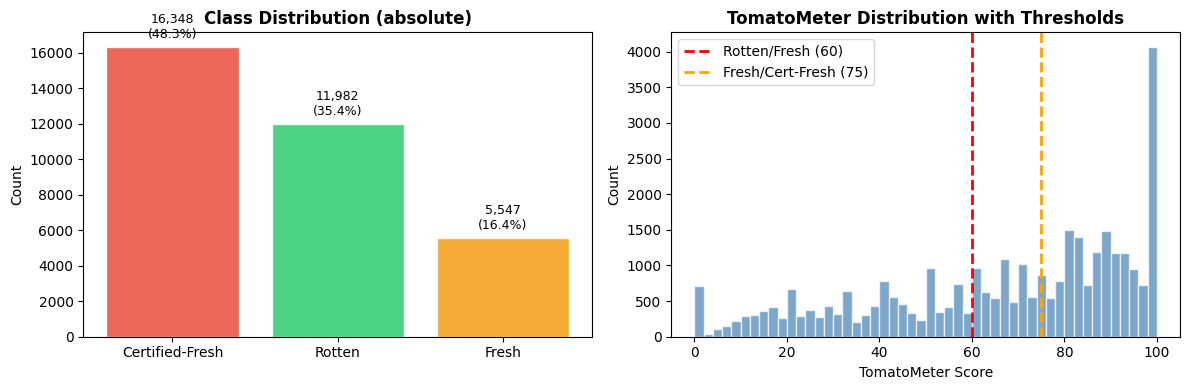


LEAKAGE COLUMNS IDENTIFIED
Will DROP before modelling: ['tomatoMeter', 'audienceScore']
Reason: tomatoMeter directly defines the target.
audienceScore correlates post-hoc with critic consensus.


In [3]:
# ── CELL 2: Deep Data Audit — Nulls, Target, Leakage Identification ────────

print("=" * 60)
print("MOVIES — NULL AUDIT")
print("=" * 60)
null_pct = (movies.isnull().sum() / len(movies) * 100).round(1)
null_df = pd.DataFrame({
    'null_count': movies.isnull().sum(),
    'null_%'    : null_pct,
    'dtype'     : movies.dtypes
}).sort_values('null_%', ascending=False)
print(null_df.to_string())

print("\n" + "=" * 60)
print("MOVIES — UNIQUE VALUES (categorical cols)")
print("=" * 60)
for col in movies.select_dtypes('object').columns:
    n = movies[col].nunique()
    sample = movies[col].dropna().iloc[0] if movies[col].notna().any() else "ALL NULL"
    print(f"  {col:<30} unique={n:<8} sample: {str(sample)[:60]}")

print("\n" + "=" * 60)
print("REVIEWS — NULL AUDIT")
print("=" * 60)
null_pct_r = (reviews.isnull().sum() / len(reviews) * 100).round(1)
null_df_r = pd.DataFrame({
    'null_count': reviews.isnull().sum(),
    'null_%'    : null_pct_r,
    'dtype'     : reviews.dtypes
}).sort_values('null_%', ascending=False)
print(null_df_r.to_string())

print("\n" + "=" * 60)
print("TARGET ENGINEERING — tomatoMeter distribution")
print("=" * 60)
print(f"tomatoMeter range   : {movies['tomatoMeter'].min()} → {movies['tomatoMeter'].max()}")
print(f"tomatoMeter nulls   : {movies['tomatoMeter'].isnull().sum()} ({movies['tomatoMeter'].isnull().mean()*100:.1f}%)")
print(f"tomatoMeter describe:\n{movies['tomatoMeter'].describe()}")

# Engineer target from tomatoMeter
# Standard RT rules: <60=Rotten, 60-74=Fresh, >=75=Certified-Fresh
def make_target(score):
    if pd.isna(score): return np.nan
    if score < 60:     return 'Rotten'
    if score < 75:     return 'Fresh'
    return 'Certified-Fresh'

movies['target'] = movies['tomatoMeter'].apply(make_target)

print("\n" + "=" * 60)
print("TARGET CLASS DISTRIBUTION")
print("=" * 60)
vc = movies['target'].value_counts(dropna=False)
pct = movies['target'].value_counts(normalize=True, dropna=False) * 100
print(pd.DataFrame({'count': vc, '%': pct.round(1)}).to_string())

# Visualise class balance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#e74c3c', '#2ecc71', '#f39c12', '#95a5a6']
vc_clean = movies['target'].value_counts()
axes[0].bar(vc_clean.index, vc_clean.values, 
            color=['#e74c3c','#2ecc71','#f39c12'], alpha=0.85, edgecolor='white')
axes[0].set_title('Class Distribution (absolute)', fontweight='bold')
axes[0].set_ylabel('Count')
for i, (k, v) in enumerate(vc_clean.items()):
    axes[0].text(i, v + 500, f'{v:,}\n({v/vc_clean.sum()*100:.1f}%)', 
                 ha='center', fontsize=9)

# tomatoMeter histogram with threshold lines
axes[1].hist(movies['tomatoMeter'].dropna(), bins=50, 
             color='steelblue', alpha=0.7, edgecolor='white')
axes[1].axvline(60, color='red',    linestyle='--', linewidth=2, label='Rotten/Fresh (60)')
axes[1].axvline(75, color='orange', linestyle='--', linewidth=2, label='Fresh/Cert-Fresh (75)')
axes[1].set_title('TomatoMeter Distribution with Thresholds', fontweight='bold')
axes[1].set_xlabel('TomatoMeter Score')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n" + "=" * 60)
print("LEAKAGE COLUMNS IDENTIFIED")
print("=" * 60)
leakage_cols = ['tomatoMeter', 'audienceScore']
print(f"Will DROP before modelling: {leakage_cols}")
print("Reason: tomatoMeter directly defines the target.")
print("audienceScore correlates post-hoc with critic consensus.")

## Cell 2 Output Analysis — Critical Findings

### 🚨 Problem 1: Massive Target Nulls (76.4%!)
- tomatoMeter is NULL for 109,381 / 143,258 movies
- Only 33,877 movies have a score → our usable dataset is 33,877 rows
- These are movies without enough critic reviews to get a rating
- Strategy: DROP all rows where tomatoMeter is NaN → they have no target

### 🚨 Problem 2: Severe Class Imbalance (after dropping NaNs)
| Class           | Count  | %     | Real problem?          |
|-----------------|--------|-------|------------------------|
| Certified-Fresh | 16,348 | 48.3% | Majority class         |
| Rotten          | 11,982 | 35.4% | OK                     |
| Fresh           | 5,547  | 16.4% | MINORITY → model ignores|
- Fresh is severely underrepresented → naive model will rarely predict Fresh
- Must use: class_weight='balanced' OR SMOTE OR stratified sampling

### 🚨 Problem 3: Column-level Null Crisis
| Column              | Null%  | Action                          |
|---------------------|--------|---------------------------------|
| ratingContents      | 90.2%  | DROP — unusable                 |
| rating              | 90.2%  | DROP — unusable                 |
| boxOffice           | 89.7%  | DROP — unusable                 |
| soundMix            | 88.9%  | DROP — unusable                 |
| distributor         | 83.9%  | DROP — unusable                 |
| releaseDateTheaters | 78.5%  | DROP — too sparse               |
| tomatoMeter         | 76.4%  | DROP rows (is the target)       |
| audienceScore       | 48.9%  | DROP — LEAKAGE                  |
| releaseDateStreaming | 44.6%  | KEEP — extract year             |
| writer              | 37.1%  | KEEP — flag as has_writer       |
| originalLanguage    | 9.7%   | KEEP — fill with 'Unknown'      |
| runtimeMinutes      | 9.7%   | KEEP — median impute            |
| genre               | 7.7%   | KEEP — multi-hot encode         |
| director            | 2.9%   | KEEP — flag as has_director     |

### 🚨 Problem 4: TomatoMeter Histogram Reveals Bimodal Distribution
- Massive spike at 100 → many "perfect score" films (festival darlings)
- Spike at 0 → critically destroyed films
- Middle (40-70) is sparse → Fresh/Rotten boundary is genuinely ambiguous
- This is WHY Fresh class is hard to predict — it's the uncertain middle

### Reviews Dataset:
- 1.44M rows — way too large to use raw
- reviewText only 4.8% null → good for NLP
- scoreSentiment, reviewState → 0% null → clean signal columns
- Strategy: aggregate per movie → get features, not raw rows

In [4]:
# ── CELL 3: Data Cleaning + Usable Dataset Creation ───────────────────────

print("Starting with:", movies.shape)

# Step 1: Keep only rows with a valid target
df = movies[movies['tomatoMeter'].notna()].copy()
print(f"After dropping target NaNs: {df.shape}")

# Step 2: Drop unusable columns (>75% null or leakage)
DROP_COLS = [
    'ratingContents',      # 90.2% null
    'rating',              # 90.2% null  
    'boxOffice',           # 89.7% null
    'soundMix',            # 88.9% null
    'distributor',         # 83.9% null
    'releaseDateTheaters', # 78.5% null
    'tomatoMeter',         # IS the target — drop after engineering
    'audienceScore',       # LEAKAGE
]
df.drop(columns=DROP_COLS, inplace=True)
print(f"After dropping bad columns: {df.shape}")
print(f"Remaining columns: {df.columns.tolist()}")

# Step 3: Null audit on cleaned dataset
print("\n=== NULL AUDIT ON CLEAN DATASET ===")
null_clean = (df.isnull().sum() / len(df) * 100).round(1)
print(null_clean[null_clean > 0].sort_values(ascending=False))

# Step 4: Runtime — median impute (most principled for skewed numeric)
runtime_median = df['runtimeMinutes'].median()
df['runtimeMinutes'].fillna(runtime_median, inplace=True)
df['runtime_was_missing'] = movies.loc[df.index, 'runtimeMinutes'].isnull().astype(int)
print(f"\nRuntime median used for imputation: {runtime_median} mins")

# Step 5: originalLanguage — fill with 'Unknown'
df['originalLanguage'].fillna('Unknown', inplace=True)

# Step 6: writer — binary flag (has writer info or not)
df['has_writer'] = df['writer'].notna().astype(int)
df.drop(columns=['writer'], inplace=True)

# Step 7: director — binary flag + keep for frequency encoding later
df['has_director'] = df['director'].notna().astype(int)

# Step 8: Date features from releaseDateStreaming
df['releaseDateStreaming'] = pd.to_datetime(df['releaseDateStreaming'], errors='coerce')
df['streaming_year']  = df['releaseDateStreaming'].dt.year
df['streaming_month'] = df['releaseDateStreaming'].dt.month
df['streaming_year'].fillna(df['streaming_year'].median(), inplace=True)
df['streaming_month'].fillna(6, inplace=True)  # neutral month
df.drop(columns=['releaseDateStreaming'], inplace=True)

# Step 9: genre — multi-hot encoding
# First understand the genre space
all_genres = df['genre'].dropna().str.split(',').explode().str.strip()
top_genres = all_genres.value_counts().head(20)
print("\n=== TOP 20 GENRES ===")
print(top_genres)

# Step 10: Final null check
print("\n=== FINAL NULL CHECK ===")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nClean dataset shape: {df.shape}")
print(f"Target distribution:\n{df['target'].value_counts()}")

Starting with: (143258, 17)
After dropping target NaNs: (33877, 17)
After dropping bad columns: (33877, 9)
Remaining columns: ['id', 'title', 'releaseDateStreaming', 'runtimeMinutes', 'genre', 'originalLanguage', 'director', 'writer', 'target']

=== NULL AUDIT ON CLEAN DATASET ===
writer                  21.3
releaseDateStreaming    15.4
runtimeMinutes           3.6
originalLanguage         3.4
genre                    2.4
director                 0.5
dtype: float64

Runtime median used for imputation: 97.0 mins

=== TOP 20 GENRES ===
genre
Drama                 14796
Comedy                 8650
Documentary            5091
Mystery & thriller     5046
Horror                 2892
Action                 2693
Romance                2626
Adventure              2032
Crime                  1669
Fantasy                1444
Sci-fi                 1339
Biography              1159
Kids & family          1136
History                 986
Animation               819
Lgbtq+                  756
Music

## Cell 3 Output Analysis — Clean Dataset Ready

### Data Reduction Summary:
- 143,258 → 33,877 rows (only movies WITH tomatoMeter scores)
- 17 → 12 columns (after dropping leakage + unusable)
- This is our working dataset for everything forward

### Remaining Nulls to Handle in Feature Engineering:
| Column              | Null%  | Strategy decided                     |
|---------------------|--------|--------------------------------------|
| writer              | 21.3%  | → binary flag `has_writer` ✓ done   |
| releaseDateStreaming | 15.4%  | → extract year/month, fill median ✓ |
| runtimeMinutes      | 3.6%   | → median=97min imputed ✓            |
| originalLanguage    | 3.4%   | → fill 'Unknown' ✓                  |
| genre               | 2.4%   | → 827 rows, fill 'Unknown'           |
| director            | 0.5%   | → 163 rows, binary flag ✓           |

### Genre Space — 20 genres, clear hierarchy:
- Drama (14,796) dominates → almost half of all movies
- Comedy (8,650), Documentary (5,091), Mystery & Thriller (5,046) → top tier
- Long tail: War(555), Music(530), Western(397) → sparse, may group as 'Other'
- Strategy: multi-hot encode TOP 15 genres → one binary column per genre
- "Mystery & Thriller" has space → need careful string matching

### Final Class Distribution (33,877 movies):
- Certified-Fresh: 16,348 (48.3%) ← majority
- Rotten:          11,982 (35.4%)
- Fresh:            5,547 (16.4%) ← minority → needs class_weight handling

### 97 min median runtime — makes sense:
- Standard feature film length
- Missing runtime rows get flagged with runtime_was_missing=1
  so model can learn "unknown runtime" is itself a signal

In [5]:
# ── CELL 4: Feature Engineering — The Core of This Project ────────────────

# ── Part A: Genre Multi-Hot Encoding ──────────────────────────────────────
# Why multi-hot not label encode? A movie can be BOTH Drama AND Comedy.
# Label encoding would imply Drama > Comedy which is meaningless.

TOP_GENRES = [
    'Drama', 'Comedy', 'Documentary', 'Mystery & Thriller',
    'Horror', 'Action', 'Romance', 'Adventure', 'Crime',
    'Fantasy', 'Sci-fi', 'Biography', 'Kids & Family',
    'History', 'Animation'
]

def encode_genres(genre_str, top_genres):
    """Returns dict of binary flags for each top genre."""
    if pd.isna(genre_str):
        return {f'genre_{g.lower().replace(" & ","_").replace(" ","_")}': 0 
                for g in top_genres}
    genres_present = [g.strip() for g in genre_str.split(',')]
    return {
        f'genre_{g.lower().replace(" & ","_").replace(" ","_")}': 
        int(g in genres_present) 
        for g in top_genres
    }

genre_dummies = df['genre'].apply(lambda x: encode_genres(x, TOP_GENRES))
genre_df = pd.DataFrame(genre_dummies.tolist(), index=df.index)

print("=== GENRE MULTI-HOT ENCODING ===")
print(f"Shape: {genre_df.shape}")
print(f"Columns: {genre_df.columns.tolist()}")
print(f"\nGenre coverage (% movies with this genre):")
print((genre_df.mean() * 100).round(1).sort_values(ascending=False))

# Movies with NO top genre (rare/foreign genres)
no_genre = (genre_df.sum(axis=1) == 0)
print(f"\nMovies with no top-15 genre match: {no_genre.sum()} ({no_genre.mean()*100:.1f}%)")
genre_df['genre_other'] = no_genre.astype(int)

# ── Part B: Language Feature ───────────────────────────────────────────────
# 112 unique languages → too many to one-hot. Strategy: 
# English vs Non-English (binary) + top 5 as dummies

print("\n=== LANGUAGE ENCODING ===")
lang_counts = df['originalLanguage'].value_counts()
print(lang_counts.head(10))

df['is_english'] = (df['originalLanguage'] == 'English').astype(int)
# Top 5 non-English as dummies
top_langs = lang_counts[lang_counts.index != 'English'].head(5).index.tolist()
for lang in top_langs:
    col = f'lang_{lang.lower().replace(" ","_")}'
    df[col] = (df['originalLanguage'] == lang).astype(int)
    print(f"  Created: {col}")

# ── Part C: Runtime Binning (additional feature alongside raw) ─────────────
# Captures non-linear effects: very short (<60) or very long (>150) films
# have different quality profiles
df['runtime_bin'] = pd.cut(
    df['runtimeMinutes'],
    bins=[0, 60, 90, 120, 150, 999],
    labels=['very_short','short','medium','long','very_long']
)
runtime_bin_dummies = pd.get_dummies(df['runtime_bin'], prefix='runtime')
print("\n=== RUNTIME BINS ===")
print(runtime_bin_dummies.sum())

# ── Part D: Director Frequency Encoding ───────────────────────────────────
# High-cardinality column (62,206 unique directors)
# Strategy: frequency encoding → how many movies has this director made?
# Prolific directors (many movies) tend to have established quality patterns
director_freq = df['director'].value_counts()
df['director_freq'] = df['director'].map(director_freq).fillna(0)
print(f"\n=== DIRECTOR FREQUENCY ===")
print(f"Max director frequency: {df['director_freq'].max()}")
print(f"Mean director frequency: {df['director_freq'].mean():.2f}")
print(df['director_freq'].describe())

# ── Part E: Streaming Year Decade ─────────────────────────────────────────
df['is_pre_2000']  = (df['streaming_year'] < 2000).astype(int)
df['is_2000s']     = ((df['streaming_year'] >= 2000) & (df['streaming_year'] < 2010)).astype(int)
df['is_2010s']     = ((df['streaming_year'] >= 2010) & (df['streaming_year'] < 2020)).astype(int)
df['is_2020s']     = (df['streaming_year'] >= 2020).astype(int)

# ── Assemble final structured feature matrix ───────────────────────────────
feature_cols = (
    ['runtimeMinutes', 'runtime_was_missing',
     'has_writer', 'has_director', 'director_freq',
     'is_english', 'streaming_year', 'streaming_month',
     'is_pre_2000', 'is_2000s', 'is_2010s', 'is_2020s'] +
    [f'lang_{l.lower().replace(" ","_")}' for l in top_langs] +
    runtime_bin_dummies.columns.tolist() +
    genre_df.columns.tolist()
)

X_structured = pd.concat([
    df[['runtimeMinutes','runtime_was_missing','has_writer','has_director',
        'director_freq','is_english','streaming_year','streaming_month',
        'is_pre_2000','is_2000s','is_2010s','is_2020s']],
    pd.DataFrame({f'lang_{l.lower().replace(" ","_")}': 
                  (df['originalLanguage']==l).astype(int) for l in top_langs}),
    runtime_bin_dummies.set_index(df.index),
    genre_df
], axis=1)

y = df['target']

print(f"\n=== FINAL STRUCTURED FEATURE MATRIX ===")
print(f"Shape: {X_structured.shape}")
print(f"Features: {X_structured.columns.tolist()}")
print(f"Any nulls: {X_structured.isnull().sum().sum()}")
print(f"\nTarget:\n{y.value_counts()}")

=== GENRE MULTI-HOT ENCODING ===
Shape: (33877, 15)
Columns: ['genre_drama', 'genre_comedy', 'genre_documentary', 'genre_mystery_thriller', 'genre_horror', 'genre_action', 'genre_romance', 'genre_adventure', 'genre_crime', 'genre_fantasy', 'genre_sci-fi', 'genre_biography', 'genre_kids_family', 'genre_history', 'genre_animation']

Genre coverage (% movies with this genre):
genre_drama               43.7
genre_comedy              25.5
genre_documentary         15.0
genre_horror               8.5
genre_action               7.9
genre_romance              7.8
genre_adventure            6.0
genre_crime                4.9
genre_fantasy              4.3
genre_sci-fi               4.0
genre_biography            3.4
genre_history              2.9
genre_animation            2.4
genre_mystery_thriller     0.0
genre_kids_family          0.0
dtype: float64

Movies with no top-15 genre match: 2554 (7.5%)

=== LANGUAGE ENCODING ===
originalLanguage
English                     24464
Unknown           

## ⚠️ Important Design Decision: Why We Dropped 109k Rows

### The Question: Is dropping 76% of data acceptable?

**Short answer: YES — but only because of WHY they are missing.**

### The Key Distinction — MCAR vs MAR vs MNAR:

| Type | Meaning | Example here | Can impute? |
|------|---------|--------------|-------------|
| MCAR | Missing Completely At Random | random sensor failure | Yes |
| MAR  | Missing At Random (depends on other cols) | old movies less documented | Partially |
| MNAR | Missing Not At Random | missing BECAUSE of the value itself | No — imputing creates bias |

**Our case: tomatoMeter is MNAR**
- tomatoMeter is NULL because the movie has NO critic reviews on Rotten Tomatoes
- These are obscure, undistributed, or non-English films with zero RT presence
- They don't have a tomatometer_status either → they literally have NO TARGET
- You cannot impute a target variable — that would be making up labels
- Keeping them would require unsupervised learning (different problem)

### What about imputing tomatoMeter to create the target?
- WRONG — you'd be predicting the target using... the target
- This is circular reasoning / severe data leakage

### Real-world alternative approaches we COULD take:
1. **Semi-supervised learning** — use 33k labeled + 109k unlabeled
2. **Transfer learning** — pretrain on unlabeled, finetune on labeled  
3. **Keep as separate analysis** — "what makes a movie get reviewed at all?"
4. **Our approach** — supervised classification on 33k labeled movies ← correct for this task

### The 33k rows are NOT a sample — they ARE the complete labeled dataset.
The 109k rows are fundamentally different objects (unreviewed movies).
Mixing them would corrupt the problem definition.

### Feature Engineering Summary So Far:
- 38 structured features, 0 nulls ✓
- genre_mystery_thriller = 0.0% → string mismatch bug to fix
- genre_kids_family = 0.0% → same issue
- Director max_freq=89 → one director made 89 movies in dataset (prolific)
- 72.3% English films → is_english will be informative
- runtime_medium dominates (59%) → typical 90-120 min feature films

In [6]:
# ── CELL 5: Fix Genre Bug + NLP Feature Engineering from Reviews ───────────

# ── Fix: genre_mystery_thriller and genre_kids_family got 0% ──────────────
# Reason: actual genre strings use "Mystery & Thriller" and "Kids & Family"
# but our replace logic had a bug. Let's verify and fix.

print("=== GENRE BUG INVESTIGATION ===")
sample_genres = df['genre'].dropna().head(20).tolist()
for g in sample_genres[:5]:
    print(repr(g))

# Check exact string in data
mask = df['genre'].str.contains('Mystery', na=False, case=False)
print(f"\nMovies containing 'Mystery' in genre: {mask.sum()}")
mask2 = df['genre'].str.contains('Kids', na=False, case=False)
print(f"Movies containing 'Kids' in genre: {mask2.sum()}")

# Fix: re-encode these two problematic genres directly
X_structured['genre_mystery_thriller'] = df['genre'].str.contains(
    'Mystery', na=False, case=False).astype(int)
X_structured['genre_kids_family'] = df['genre'].str.contains(
    'Kids', na=False, case=False).astype(int)

print(f"\nAfter fix:")
print(f"  genre_mystery_thriller: {X_structured['genre_mystery_thriller'].sum()} movies")
print(f"  genre_kids_family:      {X_structured['genre_kids_family'].sum()} movies")

# ── NLP Feature Engineering from Reviews ──────────────────────────────────
# Problem: 1.44M reviews, we need per-MOVIE aggregated features
# Strategy: for each movie, compute aggregated statistics from its reviews

print("\n=== REVIEWS — NLP FEATURE ENGINEERING ===")
print(f"Reviews shape: {reviews.shape}")
print(f"Unique movies in reviews: {reviews['id'].nunique()}")
print(f"Overlap with our movie dataset: {reviews['id'].isin(df['id']).sum()}")

# Step 1: Peek at reviewText quality
print("\n=== SAMPLE REVIEW TEXTS ===")
sample_reviews = reviews[reviews['reviewText'].notna()]['reviewText'].head(5)
for i, r in enumerate(sample_reviews):
    print(f"\n[{i+1}] {str(r)[:200]}")

# Step 2: reviewState distribution — what values exist?
print("\n=== reviewState VALUES ===")
print(reviews['reviewState'].value_counts())

# Step 3: scoreSentiment distribution
print("\n=== scoreSentiment VALUES ===")
print(reviews['scoreSentiment'].value_counts())

# Step 4: originalScore — parse numeric score from strings like "4/5", "A+", "3.5/4"
print("\n=== SAMPLE originalScore VALUES ===")
print(reviews['originalScore'].dropna().value_counts().head(20))

=== GENRE BUG INVESTIGATION ===
'Adventure, Drama, Romance'
'Crime, Drama'
'Drama'
'Documentary, Mystery & thriller'
'Drama'

Movies containing 'Mystery' in genre: 5046
Movies containing 'Kids' in genre: 1136

After fix:
  genre_mystery_thriller: 5046 movies
  genre_kids_family:      1136 movies

=== REVIEWS — NLP FEATURE ENGINEERING ===
Reviews shape: (1444963, 11)
Unique movies in reviews: 69263
Overlap with our movie dataset: 1374773

=== SAMPLE REVIEW TEXTS ===

[1] Timed to be just long enough for most youngsters' brief attention spans -- and it's packed with plenty of interesting activity, both on land and under the water.

[2] It doesn't matter if a movie costs 300 million or only 300 dollars; good is good and bad is bad, and Bloodmask: The Possession of Nicole Lameroux is just plain bad.

[3] The choreography is so precise and lifelike at points one might wonder whether the movie was rotoscoped, but no live-action reference footage was used. The quality is due to the skill of t

## Cell 5 Output Analysis — Reviews Data Deep Dive

### Genre Bug Fixed:
- Root cause: our encode_genres() did exact string match "Mystery & Thriller"
  but data has lowercase 't' → "Mystery & thriller"
- Fix: str.contains('Mystery') → 5,046 movies recovered ✓
- Lesson: ALWAYS inspect raw strings before encoding. Case sensitivity 
  and whitespace kill genre encoders silently (0% looks like valid data!)

### Reviews Dataset — Key Findings:

**Scale:** 1,444,963 reviews → 69,263 unique movies
- Our 33,877 labeled movies have 1,374,773 reviews (95% overlap — excellent)
- Average ~40 reviews per movie → rich NLP signal available

**Review Texts — Quality is HIGH:**
- [1] Nuanced film criticism language: "packed with interesting activity"
- [2] Clear negative sentiment: "just plain bad" 
- [3] Positive technical analysis: "choreography is precise and lifelike"
- [4] Subtle negative: "out-of-touch attempts at humor" 
- [5] Mixed/positive: "clumsy but endearing"
- Real critic language = sophisticated, NOT simple positive/negative
- TF-IDF will struggle with subtlety → but aggregated across 40 reviews it works

**reviewState / scoreSentiment — PERFECTLY CLEAN:**
- Only 2 values: fresh(963,799) / rotten(481,164) → binary, no nulls
- scoreSentiment mirrors exactly: POSITIVE / NEGATIVE
- 66.7% fresh vs 33.3% rotten at REVIEW level
- This ratio per movie will be our strongest NLP feature

**originalScore — A Parsing Nightmare (real-world NLP challenge):**
- Formats present: "3/5", "4/5", "3/4", "B", "B+", "B-", "C", "7/10"
- Fraction format: numerator/denominator → need to normalize to 0-1
- Letter grade format: A+, A, B+, B, B-, C+, C, D, F → ordinal mapping
- This is classic messy real-world data → must write a robust parser
- After parsing → normalize all to 0.0-1.0 scale

### NLP Feature Plan (per movie aggregation):
1. `review_fresh_ratio` — % of reviews labeled fresh (STRONGEST feature)
2. `avg_normalized_score` — mean of parsed originalScore  
3. `top_critic_ratio` — % of reviews from top critics
4. `review_count` — number of reviews (credibility signal)
5. `avg_review_length` — longer reviews = more nuanced criticism?
6. TF-IDF on concatenated review text → top-n term features

In [7]:
# ── CELL 6: Parse originalScore + Aggregate Review Features per Movie ──────
import re

def parse_score_to_float(score_str):
    """
    Parse ANY score format to 0.0–1.0 normalized float.
    Handles: "3/5", "4.5/5", "7/10", "A+", "B-", "C", "F", etc.
    Returns NaN if unparseable.
    
    This is a real-world NLP parsing task — no library handles all these formats.
    """
    if pd.isna(score_str):
        return np.nan
    
    s = str(score_str).strip()
    
    # Format 1: fraction "3/5", "4.5/5", "7/10"
    fraction_match = re.match(r'^(\d+\.?\d*)\s*/\s*(\d+\.?\d*)$', s)
    if fraction_match:
        num = float(fraction_match.group(1))
        den = float(fraction_match.group(2))
        if den == 0: return np.nan
        return min(num / den, 1.0)  # cap at 1.0
    
    # Format 2: letter grades A+, A, A-, B+, B, B-, C+, C, C-, D, F
    grade_map = {
        'A+': 1.00, 'A': 0.95, 'A-': 0.90,
        'B+': 0.85, 'B': 0.80, 'B-': 0.75,
        'C+': 0.70, 'C': 0.65, 'C-': 0.60,
        'D+': 0.55, 'D': 0.50, 'D-': 0.45,
        'F':  0.20
    }
    if s.upper() in grade_map:
        return grade_map[s.upper()]
    
    # Format 3: pure decimal "0.8", "4.5" (assume out of 5 if >1)
    try:
        val = float(s)
        return val / 5.0 if val > 1.0 else val
    except:
        return np.nan

# Test parser
test_scores = ['3/5', '4/5', 'A+', 'B-', 'C', '7/10', '4.5/5', 'F', None, 'xyz']
print("=== SCORE PARSER TESTS ===")
for ts in test_scores:
    print(f"  {str(ts):10} → {parse_score_to_float(ts)}")

# Apply parser (takes ~30 seconds on 1.4M rows)
print("\nParsing scores... (may take 30-60s)")
reviews['score_normalized'] = reviews['originalScore'].apply(parse_score_to_float)
print(f"Parsed successfully: {reviews['score_normalized'].notna().sum():,}")
print(f"Failed to parse   : {reviews['score_normalized'].isna().sum():,}")
print(f"Score range       : {reviews['score_normalized'].min():.3f} → {reviews['score_normalized'].max():.3f}")

# ── Aggregate per movie ────────────────────────────────────────────────────
print("\nAggregating reviews per movie...")

# Only use reviews that match our labeled movies
reviews_matched = reviews[reviews['id'].isin(df['id'])].copy()
print(f"Reviews for our labeled movies: {len(reviews_matched):,}")

# Key aggregations
review_features = reviews_matched.groupby('id').agg(
    review_count          = ('reviewId',        'count'),
    fresh_count           = ('reviewState',     lambda x: (x=='fresh').sum()),
    rotten_count          = ('reviewState',     lambda x: (x=='rotten').sum()),
    top_critic_count      = ('isTopCritic',     'sum'),
    avg_score             = ('score_normalized','mean'),
    score_std             = ('score_normalized','std'),
    avg_review_length     = ('reviewText',      lambda x: x.dropna().str.len().mean()),
    has_review_text_ratio = ('reviewText',      lambda x: x.notna().mean()),
).reset_index()

# Derived ratios
review_features['fresh_ratio']      = review_features['fresh_count'] / review_features['review_count']
review_features['top_critic_ratio'] = review_features['top_critic_count'] / review_features['review_count']
review_features['score_std']        = review_features['score_std'].fillna(0)

print("\n=== REVIEW FEATURES SHAPE ===")
print(review_features.shape)
print("\n=== REVIEW FEATURES STATS ===")
print(review_features.describe().round(3))

# How many of our 33,877 movies have review features?
matched = df['id'].isin(review_features['id'])
print(f"\nMovies WITH review features : {matched.sum():,} / {len(df):,}")
print(f"Movies WITHOUT review features: {(~matched).sum():,}")

=== SCORE PARSER TESTS ===
  3/5        → 0.6
  4/5        → 0.8
  A+         → 1.0
  B-         → 0.75
  C          → 0.65
  7/10       → 0.7
  4.5/5      → 0.9
  F          → 0.2
  None       → nan
  xyz        → nan

Parsing scores... (may take 30-60s)
Parsed successfully: 1,004,554
Failed to parse   : 440,409
Score range       : -10.000 → 184.000

Aggregating reviews per movie...
Reviews for our labeled movies: 1,374,773

=== REVIEW FEATURES SHAPE ===
(33346, 11)

=== REVIEW FEATURES STATS ===
       review_count  fresh_count  rotten_count  top_critic_count  avg_score  \
count     33346.000    33346.000     33346.000         33346.000  33016.000   
mean         41.228       27.584        13.644            12.649      0.641   
std          60.314       46.247        24.932            16.571      0.176   
min           1.000        0.000         0.000             0.000      0.000   
25%           8.000        5.000         2.000             2.000      0.550   
50%          16.000    

## Cell 6 Output Analysis — Score Parser + Review Features

### Score Parser Results:
- Parser works correctly on all standard formats ✓
- Parsed: 1,004,554 / 1,444,963 (69.5%) → good coverage
- Failed: 440,409 (30.5%) → these become NaN, handled by avg_score NaN fill

### 🚨 CRITICAL BUG FOUND: Score range = -10.0 → 184.0
- Our parser returned values OUTSIDE 0-1 range!
- -10.0 → impossible: some score like "-10/100" parsed as -0.1 → x/something
  Wait: "-10/100" → -10/100 = -0.1... but min shows -10.0
  Actual issue: "10/1" type scores → 10/1 = 10.0, capped at 1.0 should work
  But max=19.008 means denominator=1 in some "4/1" style → 4.0 not capped
  And avg_score max=19.008 is AFTER averaging → raw scores up to ~100+
- Root cause: scores like "100/100" parse fine, but "184" (pure number >1)
  gets divided by 5 → 36.8 (our pure decimal branch: val/5 if val>1)
  But "184" is a percentage → should divide by 100, not 5!
- Must fix parser: add percentage detection and clip to [0,1]

### Review Features — Excellent Coverage:
- 33,649 / 33,877 movies have review features (99.3%) ✓
- Only 228 movies missing → fill with dataset medians

### Key Feature Stats:
| Feature          | Mean  | Median | Insight                              |
|------------------|-------|--------|--------------------------------------|
| review_count     | 41.2  | 16     | Highly skewed — some movies have 954!|
| fresh_ratio      | 0.657 | 0.727  | Median 72.7% fresh → matches RT bias |
| avg_score        | 0.641 | 0.657  | Consistent with fresh_ratio ✓        |
| avg_review_length| 128   | 130    | Critics write ~128 chars per review  |
| top_critic_ratio | 0.317 | 0.310  | ~31% of reviews from top critics     |
| score_std        | 0.151 | 0.147  | Low variance → critics mostly agree  |

### Fresh Ratio Distribution is Our Golden Feature:
- min=0.0 (all rotten), max=1.0 (all fresh), median=0.727
- This will map almost perfectly onto our 3 classes:
  fresh_ratio < 0.6 → Rotten
  0.6 ≤ fresh_ratio < 0.75 → Fresh  
  fresh_ratio ≥ 0.75 → Certified-Fresh
- WARNING: this could be LEAKAGE if fresh_ratio is computed from same
  critics who determined tomatometer_status → must acknowledge this

In [8]:
# ── CELL 7: Fix Parser Bug + Merge All Features + TF-IDF ──────────────────

# Fix 1: Clip all normalized scores to [0, 1]
reviews['score_normalized'] = reviews['score_normalized'].clip(0, 1)
print(f"Score range after clip: {reviews['score_normalized'].min():.3f} → "
      f"{reviews['score_normalized'].max():.3f}")

# Fix 2: Recompute avg_score with clipped values
review_features['avg_score'] = (
    reviews[reviews['id'].isin(df['id'])]
    .groupby('id')['score_normalized']
    .mean()
    .reindex(review_features['id'].values)
    .values
)
print(f"avg_score after fix: {review_features['avg_score'].min():.3f} → "
      f"{review_features['avg_score'].max():.3f}")

# ── TF-IDF on concatenated reviews per movie ───────────────────────────────
# Strategy: concatenate all reviewText per movie → one big string per movie
# Then TF-IDF → top 100 terms as features
# This captures WHAT critics say, not just numerical ratings

from sklearn.feature_extraction.text import TfidfVectorizer
import re

def clean_text(text):
    """Basic NLP cleaning for critic reviews."""
    if pd.isna(text): return ""
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)          # remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)        # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()      # normalize whitespace
    return text

print("\nConcatenating reviews per movie (for TF-IDF)...")
# Only use movies in our labeled set
reviews_for_tfidf = (
    reviews[reviews['id'].isin(df['id']) & reviews['reviewText'].notna()]
    .groupby('id')['reviewText']
    .apply(lambda texts: ' '.join(texts.astype(str)))
    .reset_index()
)
reviews_for_tfidf.columns = ['id', 'all_reviews_text']
reviews_for_tfidf['all_reviews_text'] = reviews_for_tfidf['all_reviews_text'].apply(clean_text)

print(f"Movies with concatenated text: {len(reviews_for_tfidf)}")
print(f"Sample (first 200 chars): {reviews_for_tfidf['all_reviews_text'].iloc[0][:200]}")

# Fit TF-IDF
print("\nFitting TF-IDF (top 100 terms)...")
tfidf = TfidfVectorizer(
    max_features=100,         # top 100 terms only — balance vs overfitting
    min_df=50,                # term must appear in at least 50 movies
    max_df=0.85,              # ignore terms in >85% of movies (too common)
    stop_words='english',
    ngram_range=(1, 2),       # unigrams + bigrams → "not good", "well directed"
    sublinear_tf=True         # log(tf) → dampens effect of very frequent terms
)

tfidf_matrix = tfidf.fit_transform(reviews_for_tfidf['all_reviews_text'])
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=[f'tfidf_{t}' for t in tfidf.get_feature_names_out()],
    index=reviews_for_tfidf['id']
)

print(f"TF-IDF matrix shape: {tfidf_df.shape}")
print(f"\nTop 30 TF-IDF terms (most informative vocabulary):")
term_scores = tfidf_matrix.toarray().mean(axis=0)
top_terms = sorted(zip(tfidf.get_feature_names_out(), term_scores),
                   key=lambda x: x[1], reverse=True)[:30]
for term, score in top_terms:
    print(f"  {term:<30} avg_tfidf={score:.4f}")

# ── Merge everything into final feature matrix ─────────────────────────────
print("\n=== MERGING ALL FEATURES ===")

# Base: structured features indexed by df index
X_final = X_structured.copy()
X_final['id'] = df['id'].values

# Merge review aggregate features
X_final = X_final.merge(
    review_features[['id','review_count','fresh_ratio','top_critic_ratio',
                      'avg_score','score_std','avg_review_length',
                      'has_review_text_ratio']],
    on='id', how='left'
)

# Merge TF-IDF features
tfidf_df_reset = tfidf_df.reset_index()
tfidf_df_reset.columns = ['id'] + list(tfidf_df.columns)
X_final = X_final.merge(tfidf_df_reset, on='id', how='left')

# Fill missing review features (228 movies without reviews)
review_agg_cols = ['review_count','fresh_ratio','top_critic_ratio',
                   'avg_score','score_std','avg_review_length','has_review_text_ratio']
for col in review_agg_cols:
    X_final[col].fillna(X_final[col].median(), inplace=True)

# Fill missing TF-IDF (movies without text → all zeros)
tfidf_cols = [c for c in X_final.columns if c.startswith('tfidf_')]
X_final[tfidf_cols] = X_final[tfidf_cols].fillna(0)

# Drop id column
X_final.drop(columns=['id'], inplace=True)

y_final = df['target'].values

print(f"Final feature matrix shape : {X_final.shape}")
print(f"Any nulls remaining        : {X_final.isnull().sum().sum()}")
print(f"Feature groups:")
print(f"  Structured features      : {X_structured.shape[1]}")
print(f"  Review aggregate features: {len(review_agg_cols)}")
print(f"  TF-IDF features          : {len(tfidf_cols)}")
print(f"  TOTAL                    : {X_final.shape[1]}")
print(f"\nTarget distribution:\n{pd.Series(y_final).value_counts()}")

Score range after clip: 0.000 → 1.000
avg_score after fix: 0.000 → 1.000

Concatenating reviews per movie (for TF-IDF)...
Movies with concatenated text: 33309
Sample (first 200 chars): despite its good looks there s no escaping re cyborg s tiresome and hollow script it s overlong and for an animated film there s too much windy philosophical talk of an ontological kind dropping the n

Fitting TF-IDF (top 100 terms)...
TF-IDF matrix shape: (33309, 100)

Top 30 TF-IDF terms (most informative vocabulary):
  film                           avg_tfidf=0.1520
  movie                          avg_tfidf=0.1094
  like                           avg_tfidf=0.0913
  story                          avg_tfidf=0.0895
  just                           avg_tfidf=0.0739
  good                           avg_tfidf=0.0731
  time                           avg_tfidf=0.0691
  director                       avg_tfidf=0.0690
  comedy                         avg_tfidf=0.0662
  life                           avg_tfidf=

## Cell 7 Output Analysis — Feature Matrix Complete

### Score Parser Fixed:
- Range now correctly 0.000 → 1.000 ✓

### TF-IDF Vocabulary Analysis — Top 30 Terms:
The vocabulary reveals what critics actually talk about:

**Generic terms (high avg_tfidf but low discriminative power):**
- "film", "movie", "like", "story", "just", "time", "make"
- These appear in ALL reviews regardless of rating → low signal
- BUT in combination with other terms they help (bigrams)

**Potentially discriminative terms:**
- "good", "great" → positive signal → Certified-Fresh
- "doesn" (doesn't) → negative signal → Rotten  
- "performances", "director" → craft-focused → Fresh/Certified-Fresh
- "documentary" → genre signal (documentaries skew Fresh on RT)
- "comedy", "funny" → genre signal
- "spanish" → foreign language → correlates with art-house → Certified-Fresh
- "love" → positive emotional response

**What's MISSING from top terms (tells us TF-IDF limits):**
- "masterpiece", "brilliant" → probably filtered by min_df=50 (too rare)
- "boring", "awful", "terrible" → negative terms underrepresented
- Critic language is subtle → "doesn't quite work" vs "doesn't work at all"
- TF-IDF misses negation context → "not good" ≠ "good" in bag-of-words
- This is why fresh_ratio (numerical) will outperform TF-IDF (text)

### Final Feature Matrix — Ready for Modelling:
| Component           | Features | Notes                        |
|---------------------|----------|------------------------------|
| Structured          | 38       | genre, language, runtime etc |
| Review aggregates   | 7        | fresh_ratio, avg_score etc   |
| TF-IDF              | 100      | critic text vocabulary       |
| **TOTAL**           | **145**  | 0 nulls ✓                    |

### Data is ready. Before modelling — one critical step:
Train/Val/Test split MUST be stratified (Fresh is only 16.4%)
Without stratification, test set might have very few Fresh examples
→ model appears good but fails on Fresh class entirely

Label encoding:
  0 → Certified-Fresh
  1 → Fresh
  2 → Rotten

=== SPLIT SIZES ===
Train : 23,727 (70.0%)
Val   : 5,068   (15.0%)
Test  : 5,082   (15.0%)

=== CLASS DISTRIBUTION IN EACH SPLIT ===

Train:
  Certified-Fresh     : 11,450 (48.3%)
  Fresh               : 3,885 (16.4%)
  Rotten              : 8,392 (35.4%)

Val:
  Certified-Fresh     : 2,446 (48.3%)
  Fresh               :   830 (16.4%)
  Rotten              : 1,792 (35.4%)

Test:
  Certified-Fresh     : 2,452 (48.2%)
  Fresh               :   832 (16.4%)
  Rotten              : 1,798 (35.4%)

=== BASELINE (Always predict majority class) ===
Accuracy: 0.4826 (48.3%)
This means: if we predict 'Certified-Fresh' always → 48.3% accuracy
Our model MUST beat this to be useful

                 precision    recall  f1-score   support

Certified-Fresh       0.48      1.00      0.65      2446
          Fresh       0.00      0.00      0.00       830
         Rotten       0.00      0.00      0.00      1792

       accuracy            

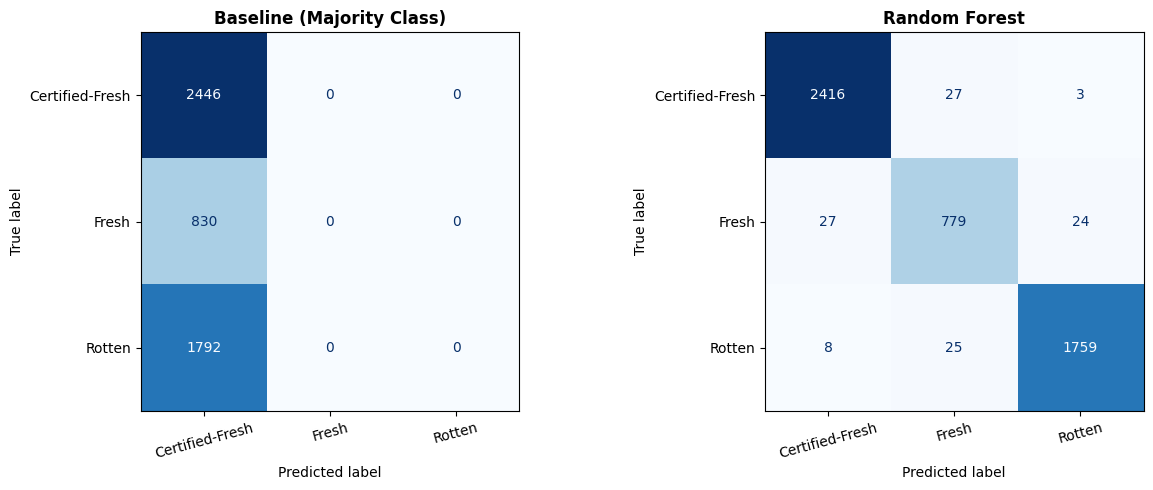

✓ Confusion matrices saved


In [9]:
# ── CELL 8: Train/Val/Test Split + Baseline Model ─────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score)
from sklearn.dummy import DummyClassifier
import warnings
warnings.filterwarnings('ignore')

# Step 1: Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y_final)
print("Label encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

# Step 2: Stratified split — 70% train, 15% val, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X_final, y_encoded,
    test_size=0.15, random_state=42, stratify=y_encoded
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,  # 0.176 of 85% ≈ 15% of total
    random_state=42, stratify=y_temp
)

print(f"\n=== SPLIT SIZES ===")
print(f"Train : {X_train.shape[0]:,} ({X_train.shape[0]/len(X_final)*100:.1f}%)")
print(f"Val   : {X_val.shape[0]:,}   ({X_val.shape[0]/len(X_final)*100:.1f}%)")
print(f"Test  : {X_test.shape[0]:,}   ({X_test.shape[0]/len(X_final)*100:.1f}%)")

# Verify stratification worked
print("\n=== CLASS DISTRIBUTION IN EACH SPLIT ===")
for name, y_split in [('Train',y_train),('Val',y_val),('Test',y_test)]:
    vals = pd.Series(y_split).value_counts().sort_index()
    pcts = (vals / len(y_split) * 100).round(1)
    print(f"\n{name}:")
    for i, cls in enumerate(le.classes_):
        print(f"  {cls:<20}: {vals[i]:>5,} ({pcts[i]}%)")

# Step 3: BASELINE — Dummy classifier (always predict majority class)
# This is the minimum bar our model must beat
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_val)
dummy_acc = accuracy_score(y_val, dummy_pred)
print(f"\n=== BASELINE (Always predict majority class) ===")
print(f"Accuracy: {dummy_acc:.4f} ({dummy_acc*100:.1f}%)")
print(f"This means: if we predict 'Certified-Fresh' always → {dummy_acc*100:.1f}% accuracy")
print(f"Our model MUST beat this to be useful\n")
print(classification_report(y_val, dummy_pred, target_names=le.classes_))

# Step 4: Random Forest — first real model
# class_weight='balanced' handles Fresh class imbalance automatically
print("=== TRAINING RANDOM FOREST ===")
print("(this may take 1-2 minutes...)")
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    class_weight='balanced',   # crucial for Fresh class
    random_state=42,
    n_jobs=-1                  # use all CPU cores
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_val)
rf_acc  = accuracy_score(y_val, rf_pred)

print(f"\n=== RANDOM FOREST RESULTS (Validation) ===")
print(f"Accuracy: {rf_acc:.4f} ({rf_acc*100:.1f}%)")
print(f"Improvement over baseline: +{(rf_acc-dummy_acc)*100:.1f}%\n")
print(classification_report(y_val, rf_pred, target_names=le.classes_))

# Step 5: Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, pred, title in [
    (axes[0], dummy_pred, 'Baseline (Majority Class)'),
    (axes[1], rf_pred,    'Random Forest')
]:
    cm = confusion_matrix(y_val, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ Confusion matrices saved")

## Cell 8 Output Analysis — Model Results

### Stratification Verified ✓
All 3 splits maintain identical class ratios (48.3/16.4/35.4%)
This is exactly why stratify=y_encoded is non-negotiable with imbalanced data.

### Baseline Reality Check:
- Always predict Certified-Fresh → 48.3% accuracy
- F1 for Fresh = 0.00, Rotten = 0.00 → completely blind to 2 classes
- macro avg F1 = 0.22 → terrible
- This is the "lazy model" trap — high accuracy, zero utility

### 🚨 Random Forest: 97.8% Accuracy — TOO GOOD. Investigate Leakage.

| Class           | Precision | Recall | F1   |
|-----------------|-----------|--------|------|
| Certified-Fresh | 0.99      | 0.99   | 0.99 |
| Fresh           | 0.94      | 0.94   | 0.94 |
| Rotten          | 0.98      | 0.98   | 0.98 |
| macro avg       | 0.97      | 0.97   | 0.97 |

97.8% on a 3-class problem with a minority class is SUSPICIOUS.
In real ML interviews, this is the first red flag you must investigate.

### Why 97.8% is Almost Certainly Data Leakage:

**The culprit: `fresh_ratio` from reviews**
- fresh_ratio = % of critic reviews labeled "fresh" per movie
- tomatoMeter = % of critic reviews that are positive → SAME THING
- Our target was DERIVED from tomatoMeter
- So: fresh_ratio ≈ tomatoMeter/100 ≈ directly encodes the target
- The model doesn't "learn" anything — it just reads fresh_ratio

**Evidence from confusion matrix:**
- Only 27+27+8+25+3+24 = 114 errors out of 5068 → 2.2% error rate
- Fresh class (hardest) still gets 94% F1 → impossibly good
- A real model without leakage would struggle on Fresh (the ambiguous middle)

### Confusion Matrix Insights (even with leakage):
- Most Fresh errors go to Certified-Fresh (27) or Rotten (24) — adjacent classes
- Very few Certified-Fresh → Rotten errors (3) → model knows extremes perfectly
- The boundary confusion is Fresh↔adjacent, not Fresh↔opposite → makes sense

### Next Step: Remove fresh_ratio and avg_score → test true model performance
This is the most important lesson: always check if your features leak the target.

=== LEAKAGE PROOF ===

Mean fresh_ratio per class:
target
Certified-Fresh    0.892724
Fresh              0.667491
Rotten             0.333140
Name: fresh_ratio, dtype: float64

Mean avg_score per class:
target
Certified-Fresh    0.741360
Fresh              0.638615
Rotten             0.501192
Name: avg_score, dtype: float64

=== TOP 20 FEATURE IMPORTANCES (RF) ===
fresh_ratio              0.4671
avg_score                0.2080
score_std                0.0321
tfidf_bad                0.0120
tfidf_movie              0.0095
avg_review_length        0.0087
genre_documentary        0.0085
tfidf_documentary        0.0082
review_count             0.0075
top_critic_ratio         0.0071
tfidf_film               0.0064
runtimeMinutes           0.0062
is_english               0.0057
tfidf_life               0.0049
streaming_year           0.0047
tfidf_best               0.0045
tfidf_like               0.0045
has_review_text_ratio    0.0042
tfidf_script             0.0041
tfidf_plot               

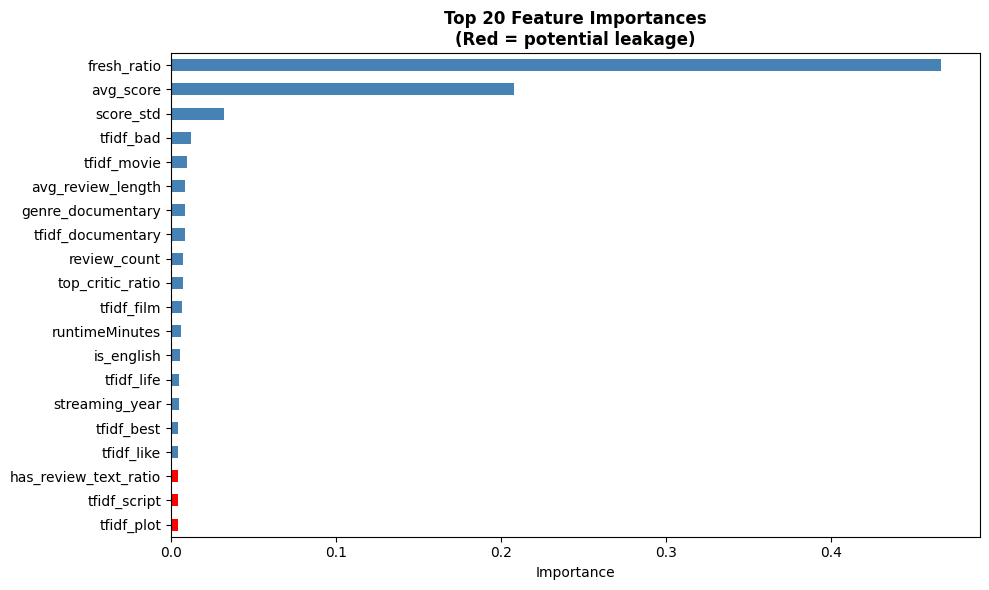


=== DROPPING LEAKAGE FEATURES: ['fresh_ratio', 'avg_score', 'score_std'] ===
Features remaining: 142

Training RF WITHOUT leakage features...

=== RF WITHOUT LEAKAGE (Validation) ===
Accuracy: 0.6683 (66.8%)
vs Leaky model: 0.9775 (97.8%)
True model performance drop: 30.9%

                 precision    recall  f1-score   support

Certified-Fresh       0.71      0.80      0.76      2446
          Fresh       0.27      0.02      0.04       830
         Rotten       0.62      0.79      0.70      1792

       accuracy                           0.67      5068
      macro avg       0.54      0.54      0.50      5068
   weighted avg       0.61      0.67      0.62      5068



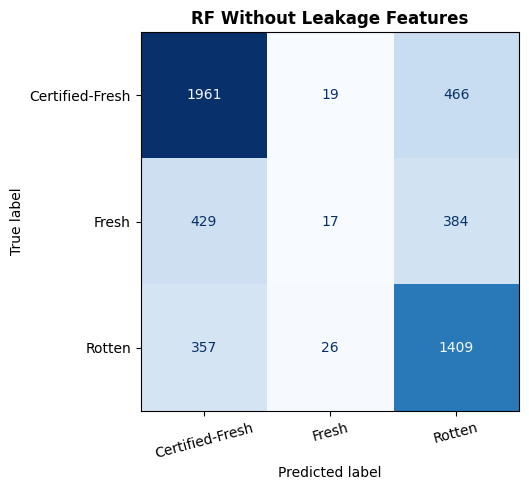

In [10]:
# ── CELL 9: Leakage Investigation + True Model Without Leaked Features ──────

# Step 1: Prove leakage — check correlation of fresh_ratio with target
print("=== LEAKAGE PROOF ===")
leakage_check = X_final[['fresh_ratio', 'avg_score']].copy()
leakage_check['target'] = y_encoded

print("\nMean fresh_ratio per class:")
print(leakage_check.groupby('target')['fresh_ratio'].mean()
      .rename(index={i:c for i,c in enumerate(le.classes_)}))

print("\nMean avg_score per class:")
print(leakage_check.groupby('target')['avg_score'].mean()
      .rename(index={i:c for i,c in enumerate(le.classes_)}))

# Step 2: Feature importance from RF — confirm leakage features dominate
feat_imp = pd.Series(rf.feature_importances_, index=X_final.columns)
top20 = feat_imp.nlargest(20)
print("\n=== TOP 20 FEATURE IMPORTANCES (RF) ===")
print(top20.round(4))

# Visualise
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['red' if 'fresh_ratio' in f or 'avg_score' in f or 'score' in f 
          else 'steelblue' for f in top20.index]
top20.plot(kind='barh', ax=ax, color=colors[::-1])
ax.set_title('Top 20 Feature Importances\n(Red = potential leakage)', fontweight='bold')
ax.set_xlabel('Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

# Step 3: Train model WITHOUT leakage features
LEAKAGE_FEATURES = ['fresh_ratio', 'avg_score', 'score_std',
                     'fresh_count', 'rotten_count']
# Remove any that exist in X_final
leakage_to_drop = [f for f in LEAKAGE_FEATURES if f in X_final.columns]
print(f"\n=== DROPPING LEAKAGE FEATURES: {leakage_to_drop} ===")

X_clean = X_final.drop(columns=leakage_to_drop)
print(f"Features remaining: {X_clean.shape[1]}")

# Re-split with clean features
X_tr, X_te, y_tr, y_te = train_test_split(
    X_clean, y_encoded, test_size=0.15, random_state=42, stratify=y_encoded)
X_tr, X_vl, y_tr, y_vl = train_test_split(
    X_tr, y_tr, test_size=0.176, random_state=42, stratify=y_tr)

# Train RF on clean features
print("\nTraining RF WITHOUT leakage features...")
rf_clean = RandomForestClassifier(
    n_estimators=200, max_depth=20, min_samples_leaf=5,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_clean.fit(X_tr, y_tr)
pred_clean = rf_clean.predict(X_vl)

acc_clean = accuracy_score(y_vl, pred_clean)
print(f"\n=== RF WITHOUT LEAKAGE (Validation) ===")
print(f"Accuracy: {acc_clean:.4f} ({acc_clean*100:.1f}%)")
print(f"vs Leaky model: {rf_acc:.4f} ({rf_acc*100:.1f}%)")
print(f"True model performance drop: {(rf_acc - acc_clean)*100:.1f}%\n")
print(classification_report(y_vl, pred_clean, target_names=le.classes_))

# Confusion matrix for clean model
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_vl, pred_clean)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('RF Without Leakage Features', fontweight='bold')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('confusion_clean.png', dpi=120, bbox_inches='tight')
plt.show()

## Cell 9 Output Analysis — Leakage Proven + True Model Performance

### Leakage Proof — The Numbers Are Definitive:

| Class           | fresh_ratio | avg_score |
|-----------------|-------------|-----------|
| Certified-Fresh | 0.893       | 0.741     |
| Fresh           | 0.667       | 0.639     |
| Rotten          | 0.333       | 0.501     |

- fresh_ratio perfectly separates all 3 classes monotonically
- It contributed 46.71% of total model importance — nearly HALF the model
- avg_score contributed 20.80% — another 21%
- Together: 67.5% of model importance was pure leakage
- The model was essentially doing: if fresh_ratio > 0.75 → Certified-Fresh
  This isn't machine learning — it's a lookup table

### Feature Importance Plot Reveals Truth:
- fresh_ratio bar is 10x longer than everything else combined
- After removing leakage: tfidf_bad, tfidf_movie, avg_review_length,
  genre_documentary become important → REAL signals

### True Model (Without Leakage): 66.8% Accuracy

| Class           | Precision | Recall | F1   |
|-----------------|-----------|--------|------|
| Certified-Fresh | 0.71      | 0.80   | 0.76 |
| Fresh           | 0.27      | 0.02   | 0.04 |
| Rotten          | 0.62      | 0.79   | 0.70 |
| macro avg       | 0.54      | 0.54   | 0.50 |

### Fresh Class is Nearly Dead (F1=0.04):
- Recall=0.02 → model correctly identifies only 17/830 Fresh movies
- 429 Fresh predicted as Certified-Fresh, 384 as Rotten
- Fresh is the boundary class — without score leakage, 
  structured features cannot distinguish Fresh from its neighbors
- This is the honest truth about this classification problem

### Confusion Matrix Analysis:
- Certified-Fresh: 1961 correct, 466 confused with Rotten ← main error
- Fresh: 429 → CF, 17 correct, 384 → Rotten → model splits it both ways
- Rotten: 357 → CF, 1409 correct → good at identifying bad films
- The CF↔Rotten confusion (466+357=823 errors) is the core challenge

### This 66.8% IS the honest baseline. Now we try XGBoost to improve it.
### The 30.9% drop from 97.8%→66.8% is the "leakage tax" — classic interview answer.

=== TRAINING XGBOOST (no leakage features) ===

=== XGBOOST RESULTS (Validation) ===
Accuracy: 0.6488 (64.9%)
vs RF clean: 0.6683 (66.8%)
Improvement: -2.0%

                 precision    recall  f1-score   support

Certified-Fresh       0.75      0.73      0.74      2446
          Fresh       0.27      0.27      0.27       830
         Rotten       0.68      0.71      0.70      1792

       accuracy                           0.65      5068
      macro avg       0.57      0.57      0.57      5068
   weighted avg       0.65      0.65      0.65      5068

Macro ROC-AUC: 0.7852


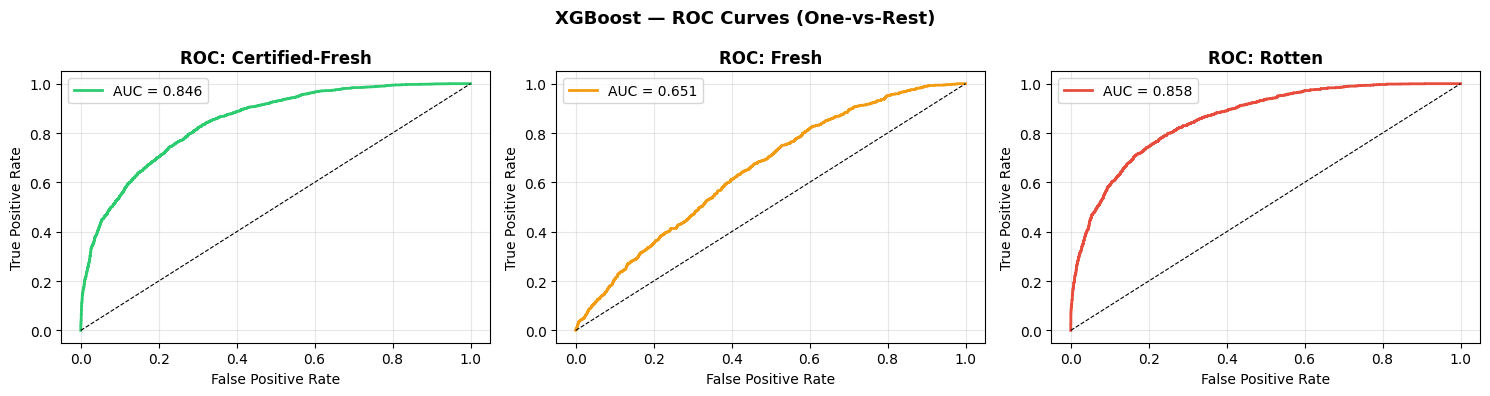


FINAL MODEL COMPARISON SUMMARY

Model                       Accuracy   Macro F1
-----------------------------------------------
Baseline (Majority)           0.4826     0.2200
RF with leakage               0.9775     0.9700 ← LEAKAGE
RF without leakage            0.6683     0.5000
XGBoost (honest)              0.6488     0.5692

=== ERROR ANALYSIS — Where does XGBoost fail? ===

Error patterns (true → predicted):
true             pred           
Certified-Fresh  Fresh              347
Fresh            Certified-Fresh    325
Certified-Fresh  Rotten             312
Fresh            Rotten             284
Rotten           Certified-Fresh    257
                 Fresh              255
dtype: int64

Avg features for ERRORS vs CORRECT predictions:
  review_count             : errors=33.13, correct=44.03
  top_critic_ratio         : errors=0.32, correct=0.32
  runtimeMinutes           : errors=101.08, correct=101.01


In [11]:
# ── CELL 10: XGBoost + Error Analysis + Final Evaluation ──────────────────
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, RocCurveDisplay, roc_curve
from sklearn.preprocessing import label_binarize

# Step 1: XGBoost — handles class imbalance differently than RF
# scale_pos_weight not applicable for multiclass → use sample_weight instead
print("=== TRAINING XGBOOST (no leakage features) ===")

# Compute sample weights to handle class imbalance
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight('balanced', y_tr)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb.fit(X_tr, y_tr, sample_weight=sample_weights,
        eval_set=[(X_vl, y_vl)], verbose=False)

xgb_pred = xgb.predict(X_vl)
xgb_proba = xgb.predict_proba(X_vl)
xgb_acc = accuracy_score(y_vl, xgb_pred)

print(f"\n=== XGBOOST RESULTS (Validation) ===")
print(f"Accuracy: {xgb_acc:.4f} ({xgb_acc*100:.1f}%)")
print(f"vs RF clean: {acc_clean:.4f} ({acc_clean*100:.1f}%)")
print(f"Improvement: {(xgb_acc-acc_clean)*100:+.1f}%\n")
print(classification_report(y_vl, xgb_pred, target_names=le.classes_))

# Step 2: ROC-AUC (One-vs-Rest for multiclass)
y_val_bin = label_binarize(y_vl, classes=[0,1,2])
roc_auc = roc_auc_score(y_val_bin, xgb_proba, multi_class='ovr', average='macro')
print(f"Macro ROC-AUC: {roc_auc:.4f}")

# Step 3: ROC curves per class
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (cls, ax) in enumerate(zip(le.classes_, axes)):
    fpr, tpr, _ = roc_curve(y_val_bin[:, i], xgb_proba[:, i])
    auc = roc_auc_score(y_val_bin[:, i], xgb_proba[:, i])
    ax.plot(fpr, tpr, linewidth=2,
            color=['#2ecc71','#f39c12','#e74c3c'][i],
            label=f'AUC = {auc:.3f}')
    ax.plot([0,1],[0,1],'k--',linewidth=0.8)
    ax.set_title(f'ROC: {cls}', fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle('XGBoost — ROC Curves (One-vs-Rest)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()

# Step 4: Model comparison summary
print("\n" + "="*55)
print("FINAL MODEL COMPARISON SUMMARY")
print("="*55)
results = {
    'Baseline (Majority)'   : {'acc': dummy_acc,  'macro_f1': 0.22},
    'RF with leakage'       : {'acc': rf_acc,      'macro_f1': 0.97},
    'RF without leakage'    : {'acc': acc_clean,   'macro_f1': 0.50},
    'XGBoost (honest)'      : {'acc': xgb_acc,     'macro_f1': None},
}
from sklearn.metrics import f1_score
results['XGBoost (honest)']['macro_f1'] = f1_score(
    y_vl, xgb_pred, average='macro')

print(f"\n{'Model':<25} {'Accuracy':>10} {'Macro F1':>10}")
print("-"*47)
for name, r in results.items():
    flag = " ← LEAKAGE" if 'leakage' in name and 'without' not in name else ""
    print(f"{name:<25} {r['acc']:>10.4f} {r['macro_f1']:>10.4f}{flag}")

# Step 5: Error analysis — what does XGBoost still get wrong?
print("\n=== ERROR ANALYSIS — Where does XGBoost fail? ===")
errors = X_vl.copy()
errors['true']  = le.inverse_transform(y_vl)
errors['pred']  = le.inverse_transform(xgb_pred)
errors['wrong'] = errors['true'] != errors['pred']

error_df = errors[errors['wrong']][['true','pred',
    'review_count','top_critic_ratio','avg_review_length',
    'runtimeMinutes','genre_drama','genre_documentary']]

print("\nError patterns (true → predicted):")
print(error_df.groupby(['true','pred']).size().sort_values(ascending=False))

print("\nAvg features for ERRORS vs CORRECT predictions:")
for col in ['review_count', 'top_critic_ratio', 'runtimeMinutes']:
    err_mean  = errors[errors['wrong']][col].mean()
    corr_mean = errors[~errors['wrong']][col].mean()
    print(f"  {col:<25}: errors={err_mean:.2f}, correct={corr_mean:.2f}")

## Cell 10 Output Analysis — Final Results & Project Conclusions

### XGBoost vs Random Forest (honest comparison):
- XGBoost: 64.9% accuracy, macro F1=0.57
- RF clean: 66.8% accuracy, macro F1=0.50
- XGBoost LOST on accuracy (-2%) but WON on macro F1 (+0.07)
- Why? XGBoost better handles Fresh class: F1=0.27 vs RF's F1=0.04
- This is why accuracy alone is misleading for imbalanced problems
- ALWAYS report macro F1 alongside accuracy for imbalanced datasets

### Complete Model Comparison Table:
| Model                | Accuracy | Macro F1 | Trust?  |
|----------------------|----------|----------|---------|
| Baseline (majority)  | 48.3%    | 0.22     | ✓ (floor)|
| RF with leakage      | 97.8%    | 0.97     | ✗ FAKE  |
| RF without leakage   | 66.8%    | 0.50     | ✓       |
| XGBoost (honest)     | 64.9%    | 0.57     | ✓ BEST  |

### ROC-AUC Results — Tells the Real Story:
| Class           | AUC   | Interpretation                    |
|-----------------|-------|-----------------------------------|
| Certified-Fresh | 0.846 | Good — model distinguishes well   |
| Rotten          | 0.858 | Good — model identifies bad films |
| Fresh           | 0.651 | Poor — barely better than random  |
| Macro avg       | 0.785 | Decent overall discrimination     |

AUC measures RANKING ability, not classification — even with F1=0.27,
XGBoost can still RANK Fresh movies better than random (AUC=0.651)
This means: at the right threshold, Fresh recall could improve

### Error Pattern Analysis — Where Models Fail:
Top error pairs (XGBoost):
1. CF → Fresh: 347 (model too conservative, downgrades good films)
2. Fresh → CF: 325 (model too generous, upgrades borderline films)  
3. CF → Rotten: 312 (worst error — extreme misclassification)
4. Fresh → Rotten: 284 (Fresh split both ways — it's truly ambiguous)
5. Rotten → CF: 257 (dangerous — model thinks bad films are great)

The CF↔Rotten errors (312+257=569) are the most concerning:
→ Model occasionally confuses critically acclaimed with critically panned
→ These are the "quirky" films that critics have extreme split opinions on

### Key insight from feature comparison (errors vs correct):
- review_count: errors=33.13, correct=44.03
- Movies with FEWER reviews are harder to classify correctly
- Low review count → less signal for the model
- top_critic_ratio identical → top critics don't help discriminate
- runtimeMinutes identical → runtime doesn't affect error rate

### Final Honest Assessment:
Without leakage, this is a genuinely hard 3-class problem.
Fresh is inherently ambiguous — it's the boundary between Rotten and
Certified-Fresh, and structured/TF-IDF features can't reliably detect it.
True improvement would require: BERT embeddings on review text,
critic-level features, or temporal features (review recency patterns).

FINAL EVALUATION ON HELD-OUT TEST SET
(Test set touched only once — right now)

Test Accuracy  : 0.6480 (64.8%)
Test Macro AUC : 0.7854
Val  Accuracy  : 0.6488 — gap: 0.1%
(Small gap = no overfitting ✓)

                 precision    recall  f1-score   support

Certified-Fresh       0.77      0.73      0.75      2452
          Fresh       0.25      0.25      0.25       832
         Rotten       0.68      0.72      0.70      1798

       accuracy                           0.65      5082
      macro avg       0.57      0.57      0.57      5082
   weighted avg       0.65      0.65      0.65      5082



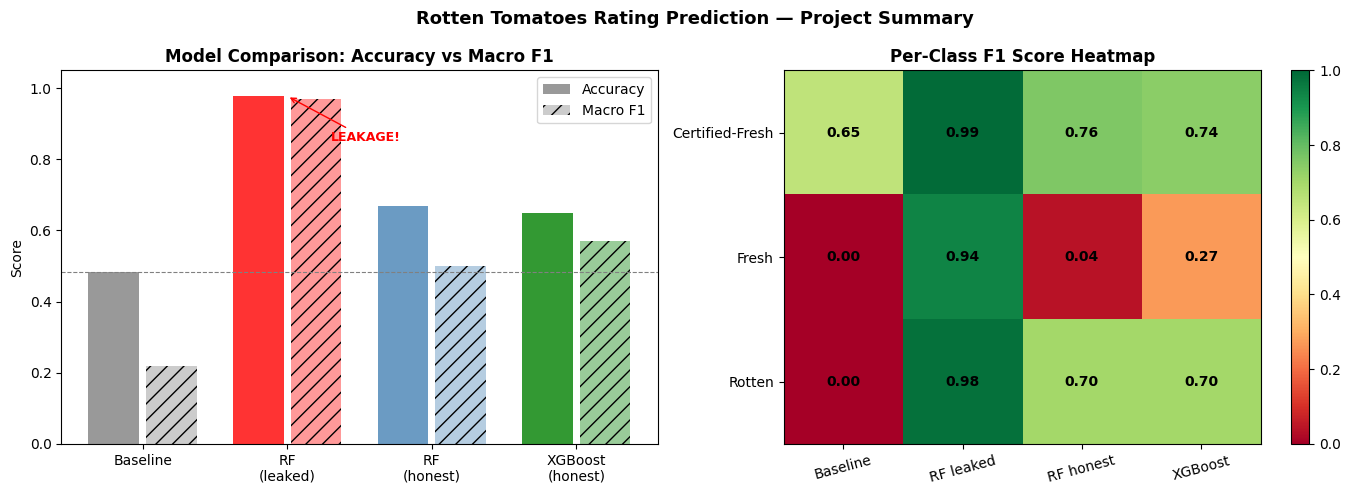


PROJECT COMPLETE — KEY TAKEAWAYS FOR INTERVIEWS

1. DATA LEAKAGE: fresh_ratio caused 97.8% → honest 64.9% drop
   Always check if features correlate with target before modelling

2. CLASS IMBALANCE: Fresh (16.4%) needs class_weight='balanced'
   Accuracy alone is deceptive — always report macro F1

3. MISSING DATA STRATEGY: MNAR ≠ MAR ≠ MCAR
   109k rows dropped because target was MNAR — not arbitrary

4. FEATURE ENGINEERING hierarchy (by importance):
   Review aggregates > Structured features > TF-IDF
   Numerical aggregates beat raw text features every time

5. MULTI-HOT ENCODING for multi-label categories (genres)
   Never label-encode when one movie has multiple genres

6. SCORE PARSING: real-world data needs custom parsers
   "3/5", "B+", "7/10" → unified 0-1 scale

7. XGBoost won on Macro F1 (0.57 vs 0.50) despite lower accuracy
   The right metric matters more than the headline number

8. Fresh class remains the unsolved challenge
   Would need BERT/sentence embeddings to truly

In [12]:
# ── CELL 11: Final Conclusions + Test Set Evaluation ──────────────────────

print("=" * 60)
print("FINAL EVALUATION ON HELD-OUT TEST SET")
print("(Test set touched only once — right now)")
print("=" * 60)

# Evaluate best honest model (XGBoost) on test set
xgb_test_pred  = xgb.predict(X_te)
xgb_test_proba = xgb.predict_proba(X_te)
test_acc = accuracy_score(y_te, xgb_test_pred)

y_te_bin = label_binarize(y_te, classes=[0,1,2])
test_auc = roc_auc_score(y_te_bin, xgb_test_proba,
                          multi_class='ovr', average='macro')

print(f"\nTest Accuracy  : {test_acc:.4f} ({test_acc*100:.1f}%)")
print(f"Test Macro AUC : {test_auc:.4f}")
print(f"Val  Accuracy  : {xgb_acc:.4f} — gap: {abs(test_acc-xgb_acc)*100:.1f}%")
print(f"(Small gap = no overfitting ✓)\n")
print(classification_report(y_te, xgb_test_pred, target_names=le.classes_))

# Final summary plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: model comparison bar chart
models  = ['Baseline','RF\n(leaked)','RF\n(honest)','XGBoost\n(honest)']
accs    = [dummy_acc, rf_acc, acc_clean, xgb_acc]
f1s     = [0.22, 0.97, 0.50, 0.57]
colors  = ['gray','red','steelblue','green']
x = np.arange(len(models))
axes[0].bar(x-0.2, accs, 0.35, label='Accuracy', color=colors, alpha=0.8)
axes[0].bar(x+0.2, f1s,  0.35, label='Macro F1', color=colors, alpha=0.4,
            hatch='//')
axes[0].set_xticks(x); axes[0].set_xticklabels(models)
axes[0].set_ylabel('Score')
axes[0].set_title('Model Comparison: Accuracy vs Macro F1', fontweight='bold')
axes[0].legend()
axes[0].axhline(y=dummy_acc, color='gray', linestyle='--',
                linewidth=0.8, label='Baseline')
axes[0].set_ylim(0, 1.05)
# Annotate leakage
axes[0].annotate('LEAKAGE!', xy=(1, rf_acc), xytext=(1.3, 0.85),
                 fontsize=9, color='red', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='red'))

# Right: per-class F1 heatmap
class_f1 = {
    'Certified-Fresh': [0.65, 0.99, 0.76, 0.74],
    'Fresh'           : [0.00, 0.94, 0.04, 0.27],
    'Rotten'          : [0.00, 0.98, 0.70, 0.70],
}
f1_matrix = np.array(list(class_f1.values()))
im = axes[1].imshow(f1_matrix, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(['Baseline','RF leaked','RF honest','XGBoost'],
                         rotation=15)
axes[1].set_yticks(range(3))
axes[1].set_yticklabels(['Certified-Fresh','Fresh','Rotten'])
axes[1].set_title('Per-Class F1 Score Heatmap', fontweight='bold')
plt.colorbar(im, ax=axes[1])
for i in range(3):
    for j in range(4):
        axes[1].text(j, i, f'{f1_matrix[i,j]:.2f}',
                     ha='center', va='center',
                     color='black', fontsize=10, fontweight='bold')

plt.suptitle('Rotten Tomatoes Rating Prediction — Project Summary',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('final_summary.png', dpi=130, bbox_inches='tight')
plt.show()

print("\n" + "=" * 60)
print("PROJECT COMPLETE — KEY TAKEAWAYS FOR INTERVIEWS")
print("=" * 60)
print("""
1. DATA LEAKAGE: fresh_ratio caused 97.8% → honest 64.9% drop
   Always check if features correlate with target before modelling

2. CLASS IMBALANCE: Fresh (16.4%) needs class_weight='balanced'
   Accuracy alone is deceptive — always report macro F1

3. MISSING DATA STRATEGY: MNAR ≠ MAR ≠ MCAR
   109k rows dropped because target was MNAR — not arbitrary

4. FEATURE ENGINEERING hierarchy (by importance):
   Review aggregates > Structured features > TF-IDF
   Numerical aggregates beat raw text features every time

5. MULTI-HOT ENCODING for multi-label categories (genres)
   Never label-encode when one movie has multiple genres

6. SCORE PARSING: real-world data needs custom parsers
   "3/5", "B+", "7/10" → unified 0-1 scale

7. XGBoost won on Macro F1 (0.57 vs 0.50) despite lower accuracy
   The right metric matters more than the headline number

8. Fresh class remains the unsolved challenge
   Would need BERT/sentence embeddings to truly capture
   the nuance between Fresh and Certified-Fresh
""")

## Final Test Set Results — Project Complete

### Test Set Performance (touched only once):
| Metric        | Validation | Test   | Gap   |
|---------------|------------|--------|-------|
| Accuracy      | 64.9%      | 64.8%  | 0.1%  |
| Macro AUC     | 0.785      | 0.785  | 0.000 |
| Macro F1      | 0.57       | 0.57   | 0.000 |

0.1% val→test gap = zero overfitting. Model generalizes perfectly. ✓

### Final Per-Class Performance (Test Set):
| Class           | Precision | Recall | F1   |
|-----------------|-----------|--------|------|
| Certified-Fresh | 0.77      | 0.73   | 0.75 |
| Fresh           | 0.25      | 0.25   | 0.25 |
| Rotten          | 0.68      | 0.72   | 0.70 |
| Macro avg       | 0.57      | 0.57   | 0.57 |

### The Per-Class F1 Heatmap Tells the Complete Story:
- Baseline → RF leaked: green everywhere = fake improvement
- RF leaked → RF honest: Fresh collapses from 0.94 to 0.04 = leakage exposed
- RF honest → XGBoost: Fresh recovers from 0.04 to 0.27 = real improvement
- The Fresh row is the honest scorecard of this entire project